In [43]:
from utils import Helper
from pathlib import Path
import re, os
import fitz
utils = Helper()
import pandas as pd
path = "language.json"

data = utils.load_json(path)
#data.keys()

In [17]:
import re

def is_page_english(text, threshold=0.8):
    # Count basic ASCII letters only (English A-Z, a-z)
    english_chars = len(re.findall(r"[A-Za-z]", text))
    # Count all non-space characters
    non_space_chars = len(re.findall(r"\S", text))

    if non_space_chars == 0:
        return False

    ratio = english_chars / non_space_chars
    return ratio >= threshold


In [35]:
text = data["gibber"]
txt = re.findall(r"[A-Za-z]", text)
non_txt = re.findall(r"\S", text)

ratio = len(txt) / len(non_txt)
def english_word_ratio(text):
    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Split into tokens
    tokens = text.split(" ")

    # Count English-like tokens (words or numbers)
    english_like = [t for t in tokens if re.fullmatch(r"[A-Za-z]+|\d+(?:[\.,]\d+)*", t)]
    ratio = len(english_like) / max(len(tokens), 1)

    return ratio

In [ ]:
all_data = []

folder_pdf = r"C:\Users\kaustubh.keny\Projects\OFFICE PROJECTS\RANDOM_FETCH_DATA\NSE_FETCH\ANNUAL_REPORTS_2026"
for idx, file in enumerate(os.listdir(folder_pdf)[:100]):

    file_path = os.path.join(folder_pdf, file)

    stem = Path(file_path).name
    print(f"COUNT: {stem}")

    doc = fitz.open(file_path)

    page_count = doc.page_count
    for page_num in range(0, page_count-1):
        page = doc[page_num]
        text = page.get_text("text")
        ratio = english_word_ratio(text)
        all_data.append([stem,page_num, ratio])


In [38]:
final_df = pd.DataFrame(all_data, columns = ['pdf','page','ratio'])
final_df.to_csv("2025_ENGLISH.csv")

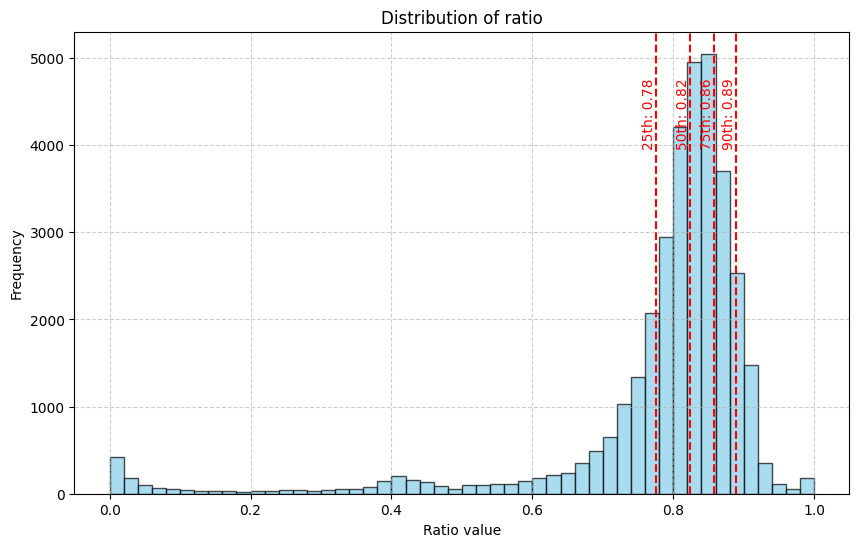

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ratio_distribution(df, column="ratio", percentiles=[25,50,75,90]):
    plt.figure(figsize=(10,6))
    plt.hist(df[column], bins=50, color="skyblue", edgecolor="black", alpha=0.7)
    plt.title(f"Distribution of {column}")
    plt.xlabel("Ratio value")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.6)

    # Compute percentile values
    values = np.percentile(df[column].dropna(), percentiles)

    for p, val in zip(percentiles, values):
        plt.axvline(val, color="red", linestyle="--", linewidth=1.5)
        plt.text(val, plt.ylim()[1]*0.9, f"{p}th: {val:.2f}",
                 rotation=90, color="red", va="top", ha="right")

    plt.show()

# Example usage
plot_ratio_distribution(final_df, "ratio")


In [47]:
path = r"C:\Users\kaustubh.keny\Projects\OFFICE PROJECTS\RANDOM_FETCH_DATA\NSE_FETCH\ANNUAL_REPORTS_2025\2025_AXISBANK.pdf"
doc = fitz.open(path)

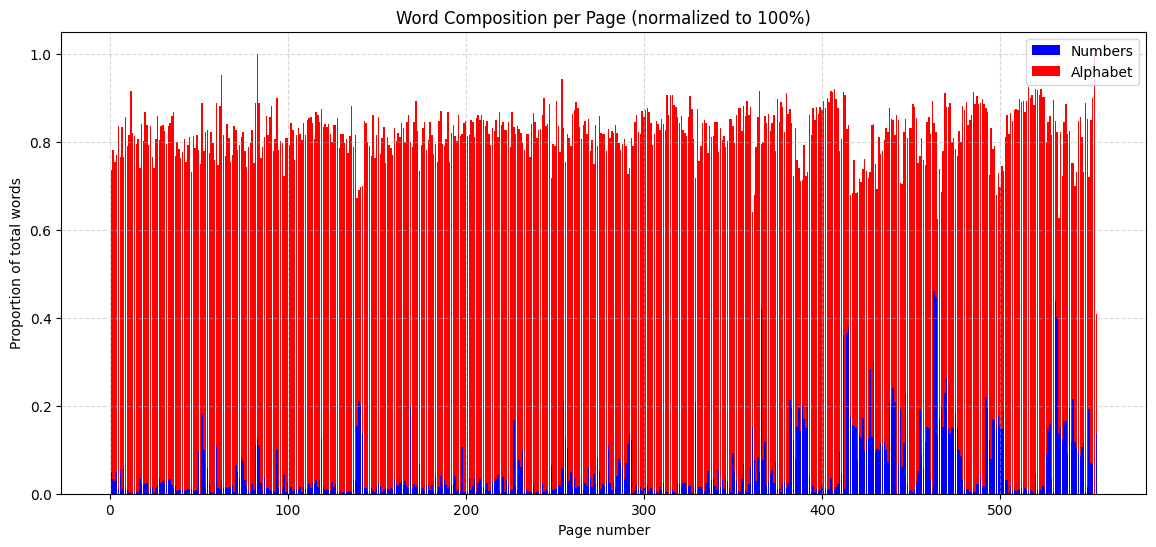

In [53]:
import re
import matplotlib.pyplot as plt
import pandas as pd

word_pattern = r"[A-Za-z]+"
num_pattern  = r"\d+(?:[\.,]\d+)*"

def page_token_counts(text):
    tokens = text.split()
    words = sum(1 for t in tokens if re.fullmatch(word_pattern, t))
    nums  = sum(1 for t in tokens if re.fullmatch(num_pattern, t))
    total = len(tokens)
    return words, nums, total

# Collect per-page data
all_data = []
for page_num in range(doc.page_count):
    text = doc[page_num].get_text("text")
    words, nums, total = page_token_counts(text)
    if total > 0:
        alpha_ratio = words / total
        num_ratio   = nums / total
    else:
        alpha_ratio = num_ratio = 0
    all_data.append([page_num+1, alpha_ratio, num_ratio])

df = pd.DataFrame(all_data, columns=["page","alpha_ratio","num_ratio"])

# Plot stacked bar chart (each bar fills to 100%)
plt.figure(figsize=(14,6))
plt.bar(df["page"], df["num_ratio"], color="blue", label="Numbers")
plt.bar(df["page"], df["alpha_ratio"], bottom=df["num_ratio"], color="red", label="Alphabet")

plt.title("Word Composition per Page (normalized to 100%)")
plt.xlabel("Page number")
plt.ylabel("Proportion of total words")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
